# 14 — Advanced Topics
**Goal:** A tour of four areas every modern ML practitioner meets at some
point — time series, recommender systems, causal inference, and
reinforcement learning. Source: Hyndman & Athanasopoulos (Forecasting),
Aggarwal Recommender Systems, Pearl (Causality), Sutton & Barto (RL).

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/learning_courses')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
np.random.seed(14)

## 1. Why these four?

| Problem | Why it is its own field |
|---|---|
| Time series | observations are *not* i.i.d.; tomorrow depends on today |
| Recommender | user-item matrix is sparse and high-d; side info helps |
| Causal | predicting Y from X is not the same as the effect of X on Y |
| Reinforcement | feedback is delayed and the action changes the world |

Each requires modifying the supervised-learning machinery from
notebooks 04-12 in a specific way.

## 2. Time series — the setup

A **time series** {y_1, y_2, ..., y_T} is a sequence of observations with a
natural order. Three components (Hyndman):

    y_t = level_t + trend_t + seasonality_t + residual_t

**Crucial difference from supervised learning:** the train/test split must
be *temporal* (no future in train). Random shuffling leaks information.
Use `sklearn.model_selection.TimeSeriesSplit`.

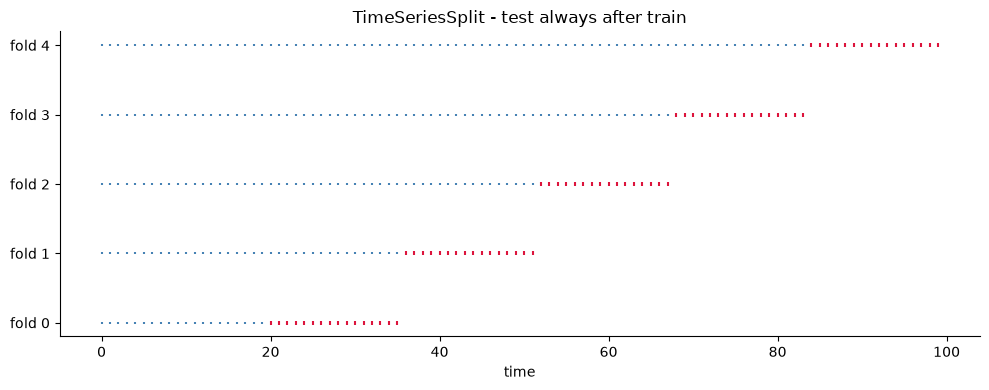

In [2]:
from sklearn.model_selection import TimeSeriesSplit
fig, ax = plt.subplots(figsize=(10, 4))
n = 100
tscv = TimeSeriesSplit(n_splits=5)
for i, (tr, te) in enumerate(tscv.split(np.arange(n))):
    ax.scatter(tr, [i]*len(tr), s=1, color='steelblue', marker='|')
    ax.scatter(te, [i]*len(te), s=8, color='crimson', marker='|')
ax.set_yticks(range(5)); ax.set_yticklabels([f'fold {i}' for i in range(5)])
ax.set_xlabel('time'); ax.set_title('TimeSeriesSplit - test always after train')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 3. Classical baselines — Naive, Seasonal Naive, ETS

Always beat ML methods with a simple baseline first.

- **Naive:** ŷ_{t+1} = y_t
- **Seasonal Naive:** ŷ_{t+1} = y_{t+1-m}  (where m is the seasonal period)
- **ETS (Holt-Winters):** exponential smoothing of level, trend, seasonality.
  `statsmodels.tsa.holtwinters.ExponentialSmoothing`.
- **ARIMA:** autoregressive integrated moving average. The classical stat
  model. `statsmodels.tsa.arima.model.ARIMA`.

These are often the *hardest* baselines to beat, especially for stable,
low-noise series.

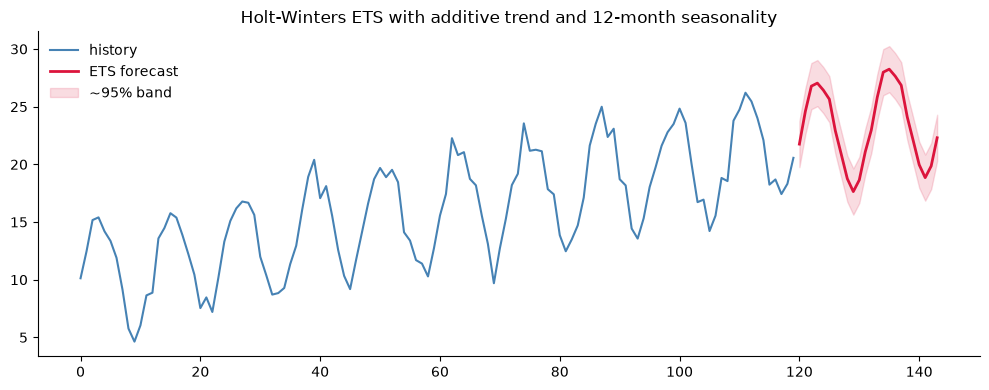

In [3]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
rng = np.random.default_rng(0)
t = np.arange(120)
y = 10 + 0.1 * t + 5 * np.sin(2*np.pi*t/12) + rng.normal(0, 1, 120)
ets = ExponentialSmoothing(y, trend='add', seasonal='add', seasonal_periods=12).fit()
fc = ets.forecast(24)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, y, color='steelblue', label='history')
ax.plot(np.arange(120, 144), fc, color='crimson', lw=2, label='ETS forecast')
ax.fill_between(np.arange(120, 144), fc - 2, fc + 2, color='crimson', alpha=0.15, label='~95% band')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
ax.set_title('Holt-Winters ETS with additive trend and 12-month seasonality')
plt.tight_layout(); plt.show()

## 4. ML for time series — feature engineering

The trick to applying sklearn models to time series is to **turn the series
into a supervised learning problem** by creating lag features.

    X_t = [y_{t-1}, y_{t-2}, ..., y_{t-p}, f(t), f(day_of_week), ...]
    y   = y_t

The lag order p is the *lookback window*. The number of features and the
amount of memory both grow with p.

In [4]:
def make_supervised(y, lags=12):
    df = pd.DataFrame({'y': y})
    for k in range(1, lags+1):
        df[f'lag_{k}'] = df['y'].shift(k)
    df = df.dropna().reset_index(drop=True)
    return df

sup = make_supervised(y, lags=12)
print('shape:', sup.shape)
print('first row:')
print(sup.head(1).T)

shape: (108, 13)
first row:
                0
y        8.874969
lag_1    8.641326
lag_2    6.046599
lag_3    4.634579
lag_4    5.766138
lag_5    9.147081
lag_6   11.904000
lag_7   13.361595
lag_8   14.194458
lag_9   15.404900
lag_10  15.170550
lag_11  12.467895
lag_12  10.125730


## 5. Modern time series models

- **Prophet** (Facebook, 2017) — decomposable trend + seasonality + holidays.
  Very robust, easy to set up, weak on cross-series learning.
- **LightGBM with lag features** — strong baseline for tabular time series
  (M5 competition winners used this).
- **DeepAR** (Salinas 2020) — RNN that outputs a parametric likelihood.
- **TFT** (Temporal Fusion Transformer, 2021) — attention with
  interpretable components.
- **N-BEATS / N-HiTS** (Oreshkin 2020) — pure-MLP, very competitive.
- **Foundation models** — TimeGPT, Chronos, Lag-Llama, TimesFM. Pretrained
  forecasters that can be fine-tuned or used zero-shot.

**Rule:** for one series and short horizon, ETS. For many series and
medium horizon, gradient-boosted trees with lag features. For long
horizons or thousands of series, a deep model.

In [5]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
sup_X = sup.drop(columns='y').values
sup_y = sup['y'].values
split = int(0.8 * len(sup))
m = GradientBoostingRegressor(n_estimators=300, max_depth=3, random_state=0)
m.fit(sup_X[:split], sup_y[:split])
pred = m.predict(sup_X[split:])
print(f'GBM MAE on last 20%: {mean_absolute_error(sup_y[split:], pred):.3f}')
print(f'Naive MAE            : {mean_absolute_error(sup_y[split:], sup_y[split-1:-1]):.3f}')

GBM MAE on last 20%: 1.252
Naive MAE            : 1.801


## 6. Recommender systems — collaborative filtering

The **user-item matrix** R ∈ ℝ^{|U|×|M|} is sparse (each user has rated few
items). Predict the missing entries.

**Matrix factorization (SVD-like, Koren 2009):**

    R ≈ P Q^T     P ∈ ℝ^{|U|×k}, Q ∈ ℝ^{|M|×k}

Each user and item is a k-dim embedding. Train by SGD on the observed
entries.

**Item-item k-NN** — for each item, find items with similar rating
patterns; recommend items similar to those the user liked.

**Implicit feedback** (clicks, views) — use ALS on P(R=1) and weight by
confidence (Hu, Koren, Volinsky 2008).

In [6]:
from sklearn.decomposition import TruncatedSVD
R = np.array([[5, 4, 0, 0, 1],
              [4, 0, 0, 2, 1],
              [1, 1, 0, 5, 4],
              [0, 0, 5, 4, 0],
              [0, 1, 4, 0, 5]])
P, Q = TruncatedSVD(n_components=2).fit_transform(R), TruncatedSVD(n_components=2).fit_transform(R.T).T
R_hat = P @ Q
print('original:\n', R)
print('reconstructed:\n', np.round(R_hat, 2))

original:
 [[5 4 0 0 1]
 [4 0 0 2 1]
 [1 1 0 5 4]
 [0 0 5 4 0]
 [0 1 4 0 5]]
reconstructed:
 [[38.58 22.01 -4.18 11.4  16.3 ]
 [24.05 14.32  4.16 13.34 15.9 ]
 [19.66 13.52 23.92 29.82 30.41]
 [-1.55  1.82 30.6  27.6  25.17]
 [ 6.85  6.41 27.54 28.09 26.88]]


## 7. Two-tower and neural recommenders

**Two-tower model** (Yi et al. 2019, used at YouTube, Google, Meta):
embed user and item in separate towers, then score by dot product. The
asymmetry lets you pre-compute item embeddings and do nearest-neighbor
search at serving time.

**Sequential recommenders** (GRU4Rec, SASRec, BERT4Rec) treat the user's
history as a sequence and use attention/RNN to predict the next item.

## 8. Causal inference — the gap between prediction and effect

**Question 1:** does X predict Y?  → supervised learning.
**Question 2:** does changing X *cause* Y to change?  → causal inference.

**Potential outcomes framework (Rubin 1974):**
For each unit i, define Y_i(1) (outcome if treated) and Y_i(0) (outcome if
control). The causal effect is τ_i = Y_i(1) - Y_i(0). We only ever observe
one of the two for each i — the **fundamental problem of causal inference**.

**Average treatment effect (ATE):**
    ATE = 𝔼[Y(1) - Y(0)] = 𝔼[Y | T=1] - 𝔼[Y | T=0]  ... only if SUTVA + ignorability

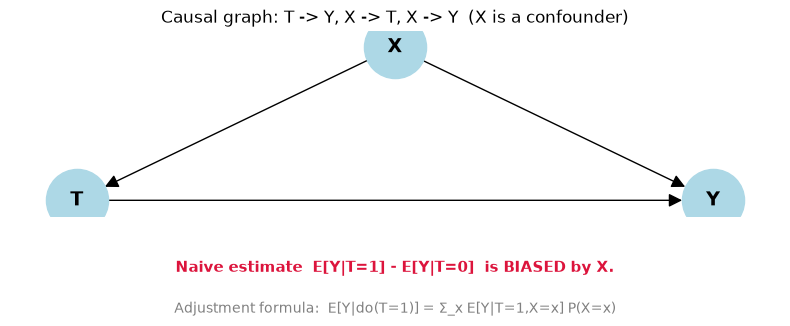

In [7]:
import networkx as nx
fig, ax = plt.subplots(figsize=(8, 4))
G = nx.DiGraph()
G.add_edges_from([('T', 'Y'), ('X', 'T'), ('X', 'Y')])
pos = {'T': (0, 0), 'Y': (3, 0), 'X': (1.5, 1.5)}
nx.draw(G, pos, ax=ax, with_labels=True, node_size=2000, node_color='lightblue',
        font_size=14, font_weight='bold', arrows=True, arrowsize=20)
ax.set_title('Causal graph: T -> Y, X -> T, X -> Y  (X is a confounder)')
ax.text(1.5, -0.7, 'Naive estimate  E[Y|T=1] - E[Y|T=0]  is BIASED by X.',
        ha='center', color='crimson', fontsize=11, weight='bold')
ax.text(1.5, -1.1, 'Adjustment formula:  E[Y|do(T=1)] = Σ_x E[Y|T=1,X=x] P(X=x)',
        ha='center', color='gray', fontsize=10)
plt.tight_layout(); plt.show()

## 9. The three core methods

1. **Randomized experiment (RCT)** — randomly assign T; the gold standard.
2. **Regression adjustment** — fit 𝔼[Y | T, X] and average over the
   observed X. The model form matters (double-ML is the modern default).
3. **Propensity score** (Rosenbaum & Rubin 1983) — model P(T=1 | X), weight
   or stratify, then estimate ATE. Inverse propensity weighting (IPW).
4. **Instrumental variables** — when X is unobserved, find a Z that
   affects T but not Y directly. 2SLS, IV regression.
5. **Difference-in-differences** — when treatment turns on at a known time
   and you have parallel trends in control.
6. **Synthetic control** — for one treated unit, build a synthetic
   comparison from a weighted combination of control units.
7. **Double / debiased machine learning** (Chernozhukov 2018) — use ML for
   nuisance estimation and orthogonalization to remove first-order bias.

In [8]:
# Toy DiD: effect of a marketing intervention
rng = np.random.default_rng(0)
n_per = 100
pre_ctrl  = rng.normal(10, 1, n_per)
pre_treat = rng.normal(11, 1, n_per)
post_ctrl  = pre_ctrl + rng.normal(0.5, 1, n_per)            # trend
post_treat = pre_treat + rng.normal(0.5, 1, n_per) + 3.0     # trend + effect

ctrl_pre,  ctrl_post  = pre_ctrl.mean(),  post_ctrl.mean()
treat_pre, treat_post = pre_treat.mean(), post_treat.mean()
naive_diff   = treat_post - treat_pre
did_estimate = (treat_post - treat_pre) - (ctrl_post - ctrl_pre)
print(f'naive before-after   : {naive_diff:.2f}   (inflated by group trend)')
print(f'DiD (parallel trend) : {did_estimate:.2f}  (true effect was 3.0)')

naive before-after   : 3.46   (inflated by group trend)
DiD (parallel trend) : 3.10  (true effect was 3.0)


## 10. Reinforcement learning — the agent-environment loop

At each step t:
1. **Observe** state s_t.
2. **Take** action a_t according to policy π(a | s).
3. **Receive** reward r_{t+1} and new state s_{t+1}.
4. **Update** policy to maximize 𝔼[Σ γ^t r_t] (discounted return).

**Two families of algorithms:**

- **Value-based** — learn V(s) or Q(s, a) and act greedily. Q-learning,
  DQN (Mnih 2015, Atari).
- **Policy gradient** — directly parameterize π_θ and update with
  ∇J = 𝔼[∇_θ log π_θ(a|s) · R]. REINFORCE, PPO, GRPO.

**Where RL shows up in 2024:**
- LLMs fine-tuned with RLHF / RLAIF / DPO.
- Robotics and autonomous driving.
- Game AI (AlphaGo, AlphaStar, OpenAI Five).
- Recommendation (long-term engagement vs. short-term clicks).
- Operations research and inventory control.

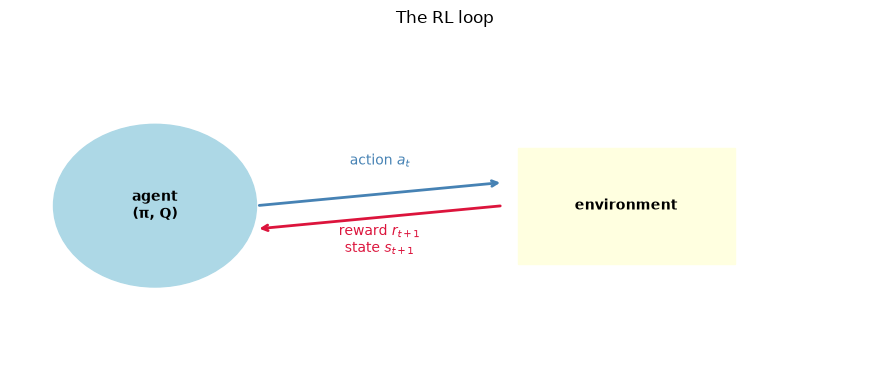

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off'); ax.set_xlim(0, 6); ax.set_ylim(0, 3)
ax.add_patch(plt.Circle((1, 1.5), 0.7, color='lightblue'))
ax.text(1, 1.5, 'agent\n(π, Q)', ha='center', va='center', fontsize=10, weight='bold')
ax.add_patch(plt.Rectangle((3.5, 1), 1.5, 1, color='lightyellow'))
ax.text(4.25, 1.5, 'environment', ha='center', va='center', fontsize=10, weight='bold')
ax.annotate('', xy=(3.4, 1.7), xytext=(1.7, 1.5),
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))
ax.text(2.55, 1.85, 'action $a_t$', ha='center', fontsize=10, color='steelblue')
ax.annotate('', xy=(1.7, 1.3), xytext=(3.4, 1.5),
            arrowprops=dict(arrowstyle='->', color='crimson', lw=2))
ax.text(2.55, 1.1, 'reward $r_{t+1}$\nstate $s_{t+1}$', ha='center', fontsize=10, color='crimson')
ax.set_title('The RL loop')
plt.tight_layout(); plt.show()

In [10]:
# Toy Q-learning on a 1-D gridworld
import numpy as np
n_states, n_actions = 7, 2  # 0=left, 1=right
goal = 6
Q = np.zeros((n_states, n_actions))
episodes = 500
for ep in range(episodes):
    s = 3
    while s != goal:
        a = np.random.choice(n_actions) if np.random.rand() < 0.1 else Q[s].argmax()
        s2 = max(0, min(n_states-1, s + (1 if a else -1)))
        r = 1.0 if s2 == goal else 0.0
        Q[s, a] += 0.1 * (r + 0.9 * Q[s2].max() - Q[s, a])
        s = s2
print('Learned Q-values:')
print(np.round(Q, 2))

Learned Q-values:
[[0.   0.  ]
 [0.   0.03]
 [0.   0.72]
 [0.59 0.81]
 [0.63 0.9 ]
 [0.75 1.  ]
 [0.   0.  ]]


## 11. The four topics at a glance

| Topic | Classic algorithm | Modern default | When to deviate |
|---|---|---|---|
| Time series | ARIMA, ETS | LightGBM + lags, N-BEATS | many series, very long horizon |
| Recommender | Matrix factorization, k-NN | Two-tower, sequential | cold start → use side info |
| Causal | DiD, IV, RCT | Double-ML, synthetic control | need an instrument or panel |
| RL | Q-learning, policy gradient | PPO, model-based RL | small state/action spaces |

**One-line advice:**
- Time series — start with ETS, then LightGBM.
- Recommender — start with two-tower if you have side info.
- Causal — start with RCT or DiD; reach for DML when you must use ML.
- RL — reach for RL only when supervised learning is genuinely the wrong
  tool.

## Summary

| Topic | Core idea |
|---|---|
| Time series | temporal split; lag features; ETS/LightGBM/N-BEATS |
| Recommender | sparse matrix completion; matrix factorization → two-tower → sequential |
| Causal | RCT > DiD > IV > DML; always ask *is this a prediction or an effect?* |
| RL | agent/environment loop; value-based or policy-gradient |

**Next:** `15_capstone_end_to_end.ipynb` - put it all together in a real
project.